# Image Quality Toolset - Getting Started

This notebook walks you through the **Image Quality Toolset**, a set of algorithms for computing:

- **MTF** (Modulation Transfer Function) — measures how well an imaging system reproduces spatial detail
- **SNR** (Signal-to-Noise Ratio) — measures the ratio of useful signal to background noise

Two methods are available:

| Method | Name | Description |
|--------|------|-------------|
| MTF | MTF Estimator | MTF computation method with parametric/non-parametric ESF models |
| SNR | SNR Estimator | Signal-to-Noise Ratio estimator |

Four test datasets are included:

| Dataset | Sensor | Config file | ROI type |
|---------|--------|-------------|----------|
| `target1/` | Sentinel-2 (Bagnolo) | `bagnolo_MTF.ini` | Shapefile |
| `target2/` | PAN target | `pan_target_MTF.ini` | Crop window |
| `target3/` | Pléiades Neo | `pneo_MTF.ini` | Shapefile |
| `target4/` | Landsat-9 (desert) | `desert_SNR.ini` | Shapefile |

---
## 1. Environment Setup

Before running this notebook, make sure you have:

1. Created the conda environment:
   ```bash
   conda env create -f image_quality_toolset/environment.yml
   conda activate mtf
   ```

2. Set the required environment variable:
   ```bash
   conda env config vars set IMAGE_QUALITY_TOOL_HOME=/absolute/path/to/image_quality_tool
   conda deactivate && conda activate mtf
   ```

3. Set the PYTHONPATH:
   ```bash
   conda env config vars set PYTHONPATH=$IMAGE_QUALITY_TOOL_HOME
   conda deactivate && conda activate mtf
   ```

The cell below verifies that your environment is correctly configured.

In [1]:
import os
import sys

# Check IMAGE_QUALITY_TOOL_HOME
iqt_home = os.environ.get("IMAGE_QUALITY_TOOL_HOME")
if iqt_home is None:
    raise EnvironmentError(
        "IMAGE_QUALITY_TOOL_HOME is not set.\n"
        "Run: conda env config vars set IMAGE_QUALITY_TOOL_HOME=/path/to/image_quality_toolset"
    )

# Add both the repo root and the image_quality_toolset subpackage to sys.path
# so that `scripts.*` and `algorithms.*` are importable directly.
iqt_pkg = os.path.join(iqt_home, "image_quality_toolset")
for p in [iqt_home, iqt_pkg]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f"IMAGE_QUALITY_TOOL_HOME = {iqt_home}")
print(f"Python version: {sys.version}")

# Verify key dependencies
import numpy as np
import matplotlib
import scipy
from osgeo import gdal
from qgis.core import QgsApplication

print(f"numpy      {np.__version__}")
print(f"matplotlib {matplotlib.__version__}")
print(f"scipy      {scipy.__version__}")
print(f"GDAL       {gdal.__version__}")
print("\nAll dependencies OK.")

IMAGE_QUALITY_TOOL_HOME = /home/romain/work/qgis-image-quality-toolset
Python version: 3.9.18 | packaged by conda-forge | (main, Dec 23 2023, 16:33:10) 
[GCC 12.3.0]
numpy      2.0.2
matplotlib 3.9.4
scipy      1.13.1
GDAL       3.10.2

All dependencies OK.


In [2]:

# Display PYTHONPATH and verify qgis-image-quality-toolset is included
pythonpath = os.environ.get("PYTHONPATH", "")

print("=== PYTHONPATH ===")
if pythonpath:
    for p in pythonpath.split(os.pathsep):
        print(f"  {p}")
else:
    print("  (not set)")

print()
keyword = "qgis-image-quality-toolset"
in_pythonpath = any(keyword in p for p in pythonpath.split(os.pathsep))
in_syspath    = any(keyword in p for p in sys.path)

print(f"'{keyword}' in PYTHONPATH : {'✓ YES' if in_pythonpath else '✗ NOT FOUND'}")
print(f"'{keyword}' in sys.path   : {'✓ YES' if in_syspath    else '✗ NOT FOUND'}")


=== PYTHONPATH ===
  /home/romain/miniconda3/envs/mtf/share/qgis/python/plugins
  /home/romain/miniconda3/envs/mtf/share/qgis/python
  /home/romain/miniconda3/envs/mtf/share/qgis/python/plugins
  /home/romain/miniconda3/envs/mtf/share/qgis/python
  /home/romain/work/qgis-image-quality-toolset/image_quality_toolset

'qgis-image-quality-toolset' in PYTHONPATH : ✓ YES
'qgis-image-quality-toolset' in sys.path   : ✓ YES


In [3]:
# Common imports used throughout this notebook
import threading
import time
import matplotlib.pyplot as plt
%matplotlib inline

import ipywidgets as widgets
from IPython.display import display

from scripts.mtf_computer import process_algorithm, load_config, crop_image


def run_with_progress(config_file, description="Processing"):
    """Run process_algorithm with an animated progress bar and debug info."""
    config = load_config(config_file)
    if config.get('debug_dir'):
        debug_rel = os.path.relpath(config['debug_dir'])
        print(f"Debug images are being generated under: {debug_rel}")

    progress = widgets.FloatProgress(
        value=0, min=0, max=100,
        description=description,
        bar_style='info',
        layout=widgets.Layout(width='50%'),
    )
    display(progress)

    result = [None]
    error = [None]

    def _run():
        try:
            result[0] = process_algorithm(config_file)
        except Exception as e:
            error[0] = e

    t = threading.Thread(target=_run)
    t.start()

    step = 0
    while t.is_alive():
        step = min(step + 2, 90)
        progress.value = step
        time.sleep(0.3)

    progress.value = 100
    progress.bar_style = 'success'
    progress.description = 'Done!'

    if error[0]:
        raise error[0]

    return result[0]

---
## 2. Discover the Test Data

The toolset ships with four datasets so you can experiment right away.

/home/romain/miniconda3/envs/mtf/lib/python3.9/site-packages/osgeo/gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


Bagnolo shape : (1000, 1000)
Value range   : [1113.0, 19120.0]


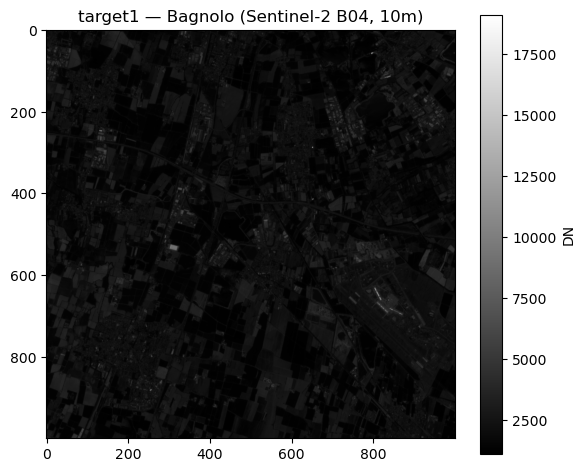

In [4]:
# ----- Dataset 1 (target1): Bagnolo - Sentinel-2 raster with shapefile ROI -----
bagnolo_path = os.path.join(iqt_home, "test", "data", "target1",
                            "T32TNR_20250619T101559_B04_10m_mtf_roi.tiff")

ds = gdal.Open(bagnolo_path, gdal.GA_ReadOnly)
bagnolo_array = ds.GetRasterBand(1).ReadAsArray().astype(np.float64)
ds = None

print(f"Bagnolo shape : {bagnolo_array.shape}")
print(f"Value range   : [{bagnolo_array.min():.1f}, {bagnolo_array.max():.1f}]")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(bagnolo_array, cmap="gray")
ax.set_title("target1 — Bagnolo (Sentinel-2 B04, 10m)")
plt.colorbar(im, ax=ax, label="DN")
plt.tight_layout()
plt.show()

PAN target shape : (80, 80)
Value range      : [2655.0, 12795.0]


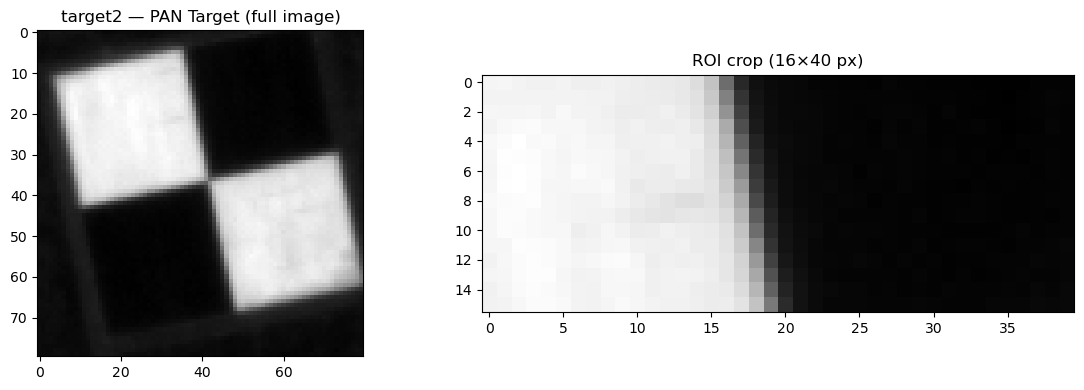

In [5]:
# ----- Dataset 2 (target2): PAN target - small edge image with crop window ROI -----
pan_path = os.path.join(iqt_home, "test", "data", "target2",
                        "S100199aI_002_2_PAN_L0R_mtf_target.tif")

ds = gdal.Open(pan_path, gdal.GA_ReadOnly)
pan_array = ds.GetRasterBand(1).ReadAsArray().astype(np.float64)
ds = None

print(f"PAN target shape : {pan_array.shape}")
print(f"Value range      : [{pan_array.min():.1f}, {pan_array.max():.1f}]")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(pan_array, cmap="gray")
axes[0].set_title("target2 — PAN Target (full image)")

# Show the ROI crop used in pan_target_MTF.ini
roi = {"line": 13, "pixel": 21, "line_number": 16, "pixel_number": 40}
crop = pan_array[roi["line"]:roi["line"]+roi["line_number"],
                 roi["pixel"]:roi["pixel"]+roi["pixel_number"]]
axes[1].imshow(crop, cmap="gray")
axes[1].set_title(f"ROI crop ({crop.shape[0]}×{crop.shape[1]} px)")

plt.tight_layout()
plt.show()

Pléiades Neo bands : 3
Raster size        : 4427 × 4342 px
Band 1 value range : [1.0, 31944.0]


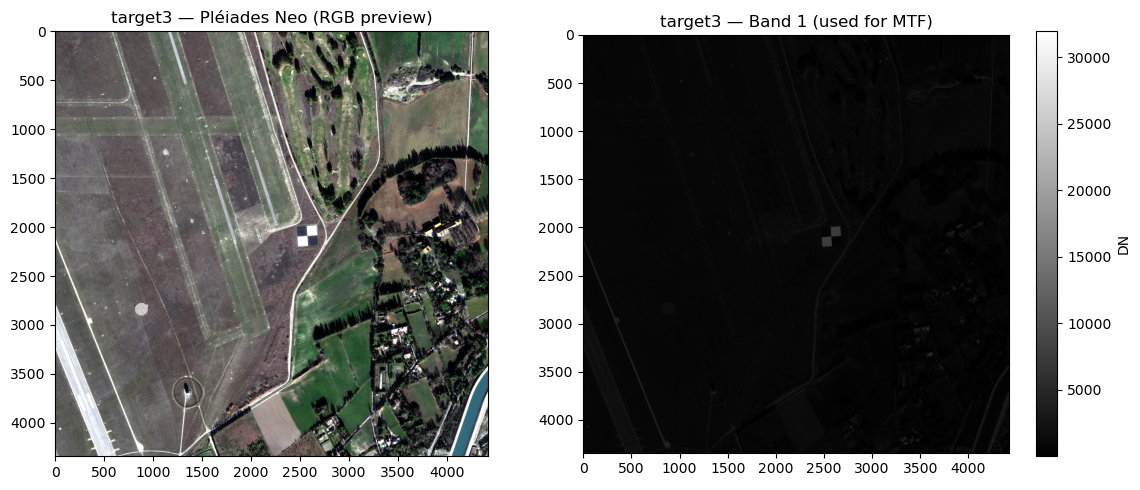

In [6]:
# ----- Dataset 3 (target3): Pléiades Neo - RGB MTF target with shapefile ROI -----
pneo_path = os.path.join(iqt_home, "test", "data", "target3",
                         "IMG_PNEO4_202312251040354_PMS-N_SEN_PWOI_000184796_RGB_MTF_TARGET.tif")

ds = gdal.Open(pneo_path, gdal.GA_ReadOnly)
n_bands = ds.RasterCount
print(f"Pléiades Neo bands : {n_bands}")
print(f"Raster size        : {ds.RasterXSize} × {ds.RasterYSize} px")

# Read R, G, B bands (bands 1, 2, 3) and build an 8-bit RGB preview
def band_to_uint8(band_array):
    p2, p98 = np.percentile(band_array, (2, 98))
    clipped = np.clip(band_array, p2, p98)
    return ((clipped - p2) / (p98 - p2) * 255).astype(np.uint8)

rgb = np.stack([
    band_to_uint8(ds.GetRasterBand(b).ReadAsArray().astype(np.float64))
    for b in (1, 2, 3)
], axis=-1)
band1 = ds.GetRasterBand(1).ReadAsArray().astype(np.float64)
ds = None

print(f"Band 1 value range : [{band1.min():.1f}, {band1.max():.1f}]")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(rgb)
axes[0].set_title("target3 — Pléiades Neo (RGB preview)")

im = axes[1].imshow(band1, cmap="gray")
axes[1].set_title("target3 — Band 1 (used for MTF)")
plt.colorbar(im, ax=axes[1], label="DN")

plt.tight_layout()
plt.show()

Landsat-9 desert shape : (1000, 1000)
Value range            : [66.53, 182.11]


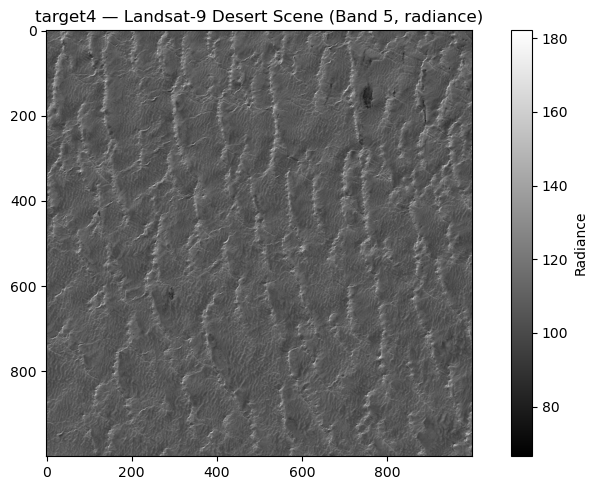

In [7]:
# ----- Dataset 4 (target4): Landsat-9 desert - single-band radiance image with shapefile ROI -----
desert_path = os.path.join(iqt_home, "test", "data", "target4",
                           "LC09_L1TP_181040_20211121_20230505_02_T1_B5_rad_crop_2.tif")

ds = gdal.Open(desert_path, gdal.GA_ReadOnly)
desert_array = ds.GetRasterBand(1).ReadAsArray().astype(np.float64)
ds = None

print(f"Landsat-9 desert shape : {desert_array.shape}")
print(f"Value range            : [{desert_array.min():.2f}, {desert_array.max():.2f}]")

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(desert_array, cmap="gray")
ax.set_title("target4 — Landsat-9 Desert Scene (Band 5, radiance)")
plt.colorbar(im, ax=ax, label="Radiance")
plt.tight_layout()
plt.show()

---
## 3. MTF on PAN Target (Crop Window ROI)

We use `pan_target_MTF.ini`, which defines the ROI as a pixel crop window directly in the config — no shapefile needed.

The MTF method implements the following pipeline:
1. Image oversampling & rotation
2. Non-equally-spaced ESF extraction
3. Parametric or non-parametric ESF model fitting
4. Sgolay filtering → LSF → FFT → MTF curve

### Key parameters

| Parameter | Description | Values |
|-----------|-------------|--------|
| `radiometric_scale` | Radiance conversion factor | float |
| `radiometric_offset` | Offset correction | float |
| `px_margin` | Pixel margin for edge extraction | int |
| `edge_direction` | Edge orientation | `AL` (Along-Track) / `CT` (Cross-Track) |
| `method_type` | ESF interpolation | `PARAM` or `NON_PARAM` |
| `esf_model` | Parametric model | `sigmoid`, `esf_tanh`, `esf_fermi`, `esf_gauss_exp_param` |

In [8]:
# Run MTF on the PAN target (crop window ROI)
config_pan_mtf = os.path.join(iqt_home, "test", "data", "config_files", "pan_target_MTF.ini")

print("=== Configuration ===")
with open(config_pan_mtf) as f:
    print(f.read())

=== Configuration ===
[input]
image_path = $IMAGE_QUALITY_TOOL_HOME/test/data/target2/S100199aI_002_2_PAN_L0R_mtf_target.tif
#ROI = $IMAGE_QUALITY_TOOL_HOME/test/data/target2/shapefile/mtf_mire.shp
ROI = {'line': 13, 'pixel': 21, 'line_number': 16, 'pixel_number': 40}

[parameters]
# MANDATORY PARAMETERS
method = MTF
band = 1

# METHOD 2 PARAMETERS
scale = 0.01
offset = 1
px_margin = 0 
edge_direction = AL
esf_model = sigmoid
sampling = 0.2
# input_angle = 5.0  # optional: if set, skips angle estimation from refineEdgeSubPx

[debug]
dir = $IMAGE_QUALITY_TOOL_HOME/output/pan_target_m2




---
## 4. MTF on Bagnolo (Shapefile ROI)

We use `bagnolo_MTF.ini`, which references a shapefile to define the ROI. This is the typical workflow for real satellite imagery where the edge target is delineated in a GIS tool.

In [9]:
# Run MTF on the Bagnolo Sentinel-2 dataset (shapefile ROI)
config_bagnolo_mtf = os.path.join(iqt_home, "test", "data", "config_files", "bagnolo_MTF.ini")

print("=== Configuration ===")
with open(config_bagnolo_mtf) as f:
    print(f.read())

=== Configuration ===
[input]
image_path = $IMAGE_QUALITY_TOOL_HOME/test/data/target1/T32TNR_20250619T101559_B04_10m_mtf_roi.tiff
ROI = $IMAGE_QUALITY_TOOL_HOME/test/data/target1/shapefile/mtf_al_bagnolo.shp

[parameters]
# MANDATORY PARAMETERS
method = MTF
band = 1

# METHOD 2 PARAMETERS
scale = 0.01
offset = 0
px_margin = 0
edge_direction = AL
esf_model = sigmoid  
# sigmoid|esf_tanh|esf_fermi|esf_gauss_exp_param|sigmoid|esf_loess|esf_to_eq_space_polynomial
sampling = 0.2
# input_angle = 5.0  # optional: if set, skips angle estimation from refineEdgeSubPx

[debug]
dir = $IMAGE_QUALITY_TOOL_HOME/output/bagnolo_raster_m2



Debug images are being generated under: output/bagnolo_raster_m2


FloatProgress(value=0.0, bar_style='info', description='MTF Bagnolo:', layout=Layout(width='50%'))

Application path not initialized
Application path not initialized
Application path not initialized
Application path not initialized
Application path not initialized
Application path not initialized
Application path not initialized
Application path not initialized
QObject::startTimer: Timers can only be used with threads started with QThread


 -- MTF AC Track         --
Number of processed BINs / Total : 104 / 141   :
Number of Oversample Edge Profile   : 166
PSF Extent Radius 10.8 pixels
- Compute RER on normalize Edge Spread Function
- Compute HEE on normalize Edge Spread Function
   - Edge width (period)      : 17.60 pixels
   - Nyquist @ L_w/2          : 8.80 pixels
Frequence / MTF  : 0.0000 / 1.0000
Frequence / MTF  : 0.0568 / 0.9185
Frequence / MTF  : 0.1136 / 0.7225
Frequence / MTF  : 0.1705 / 0.5039
Frequence / MTF  : 0.2273 / 0.3227
Frequence / MTF  : 0.2841 / 0.1949
Frequence / MTF  : 0.3409 / 0.1128
Frequence / MTF  : 0.3977 / 0.0633
Frequence / MTF  : 0.4545 / 0.0346
Frequence / MTF  : 0.5114 / 0.0184
Frequence / MTF  : 0.5682 / 0.0096
Frequence / MTF  : 0.6250 / 0.0049
Frequence / MTF  : 0.6818 / 0.0024
Frequence / MTF  : 0.7386 / 0.0012
Frequence / MTF  : 0.7955 / 0.0005
Frequence / MTF  : 0.8523 / 0.0002
Frequence / MTF  : 0.9091 / 0.0001
MTF at Nyquist frequency fn=fe/2 (interpolated) : 0.02


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

 Show AL Edge


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

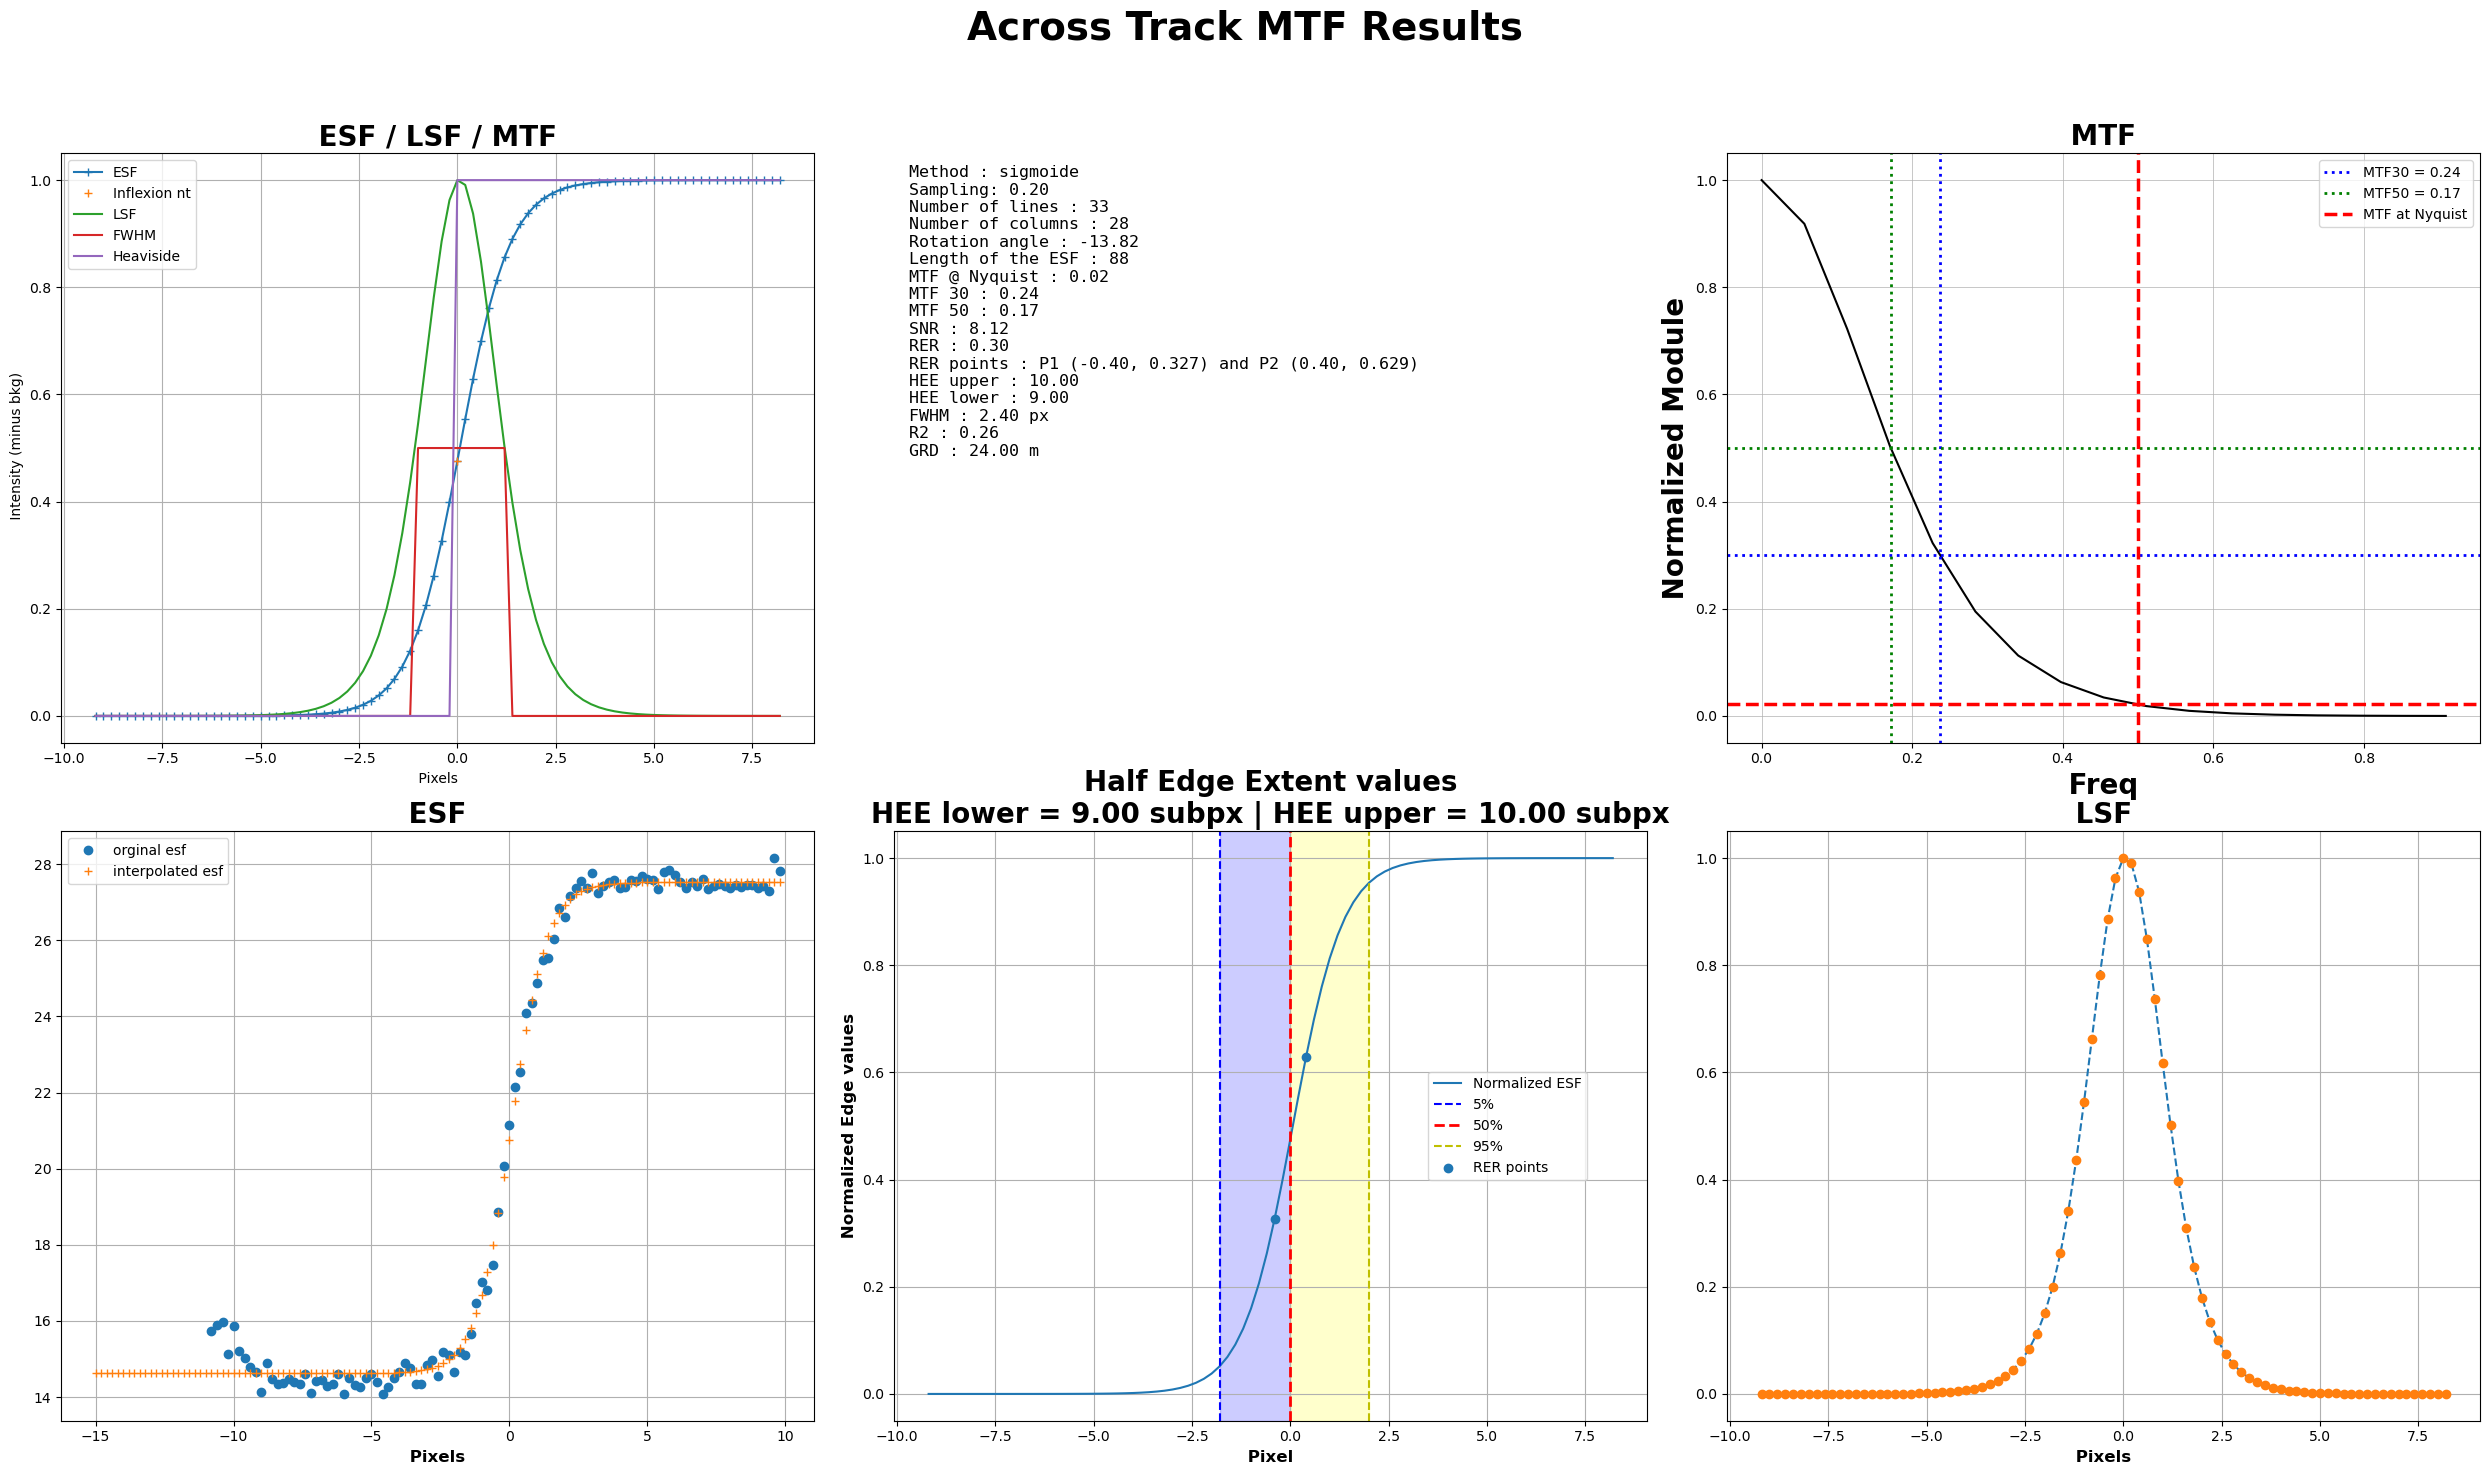

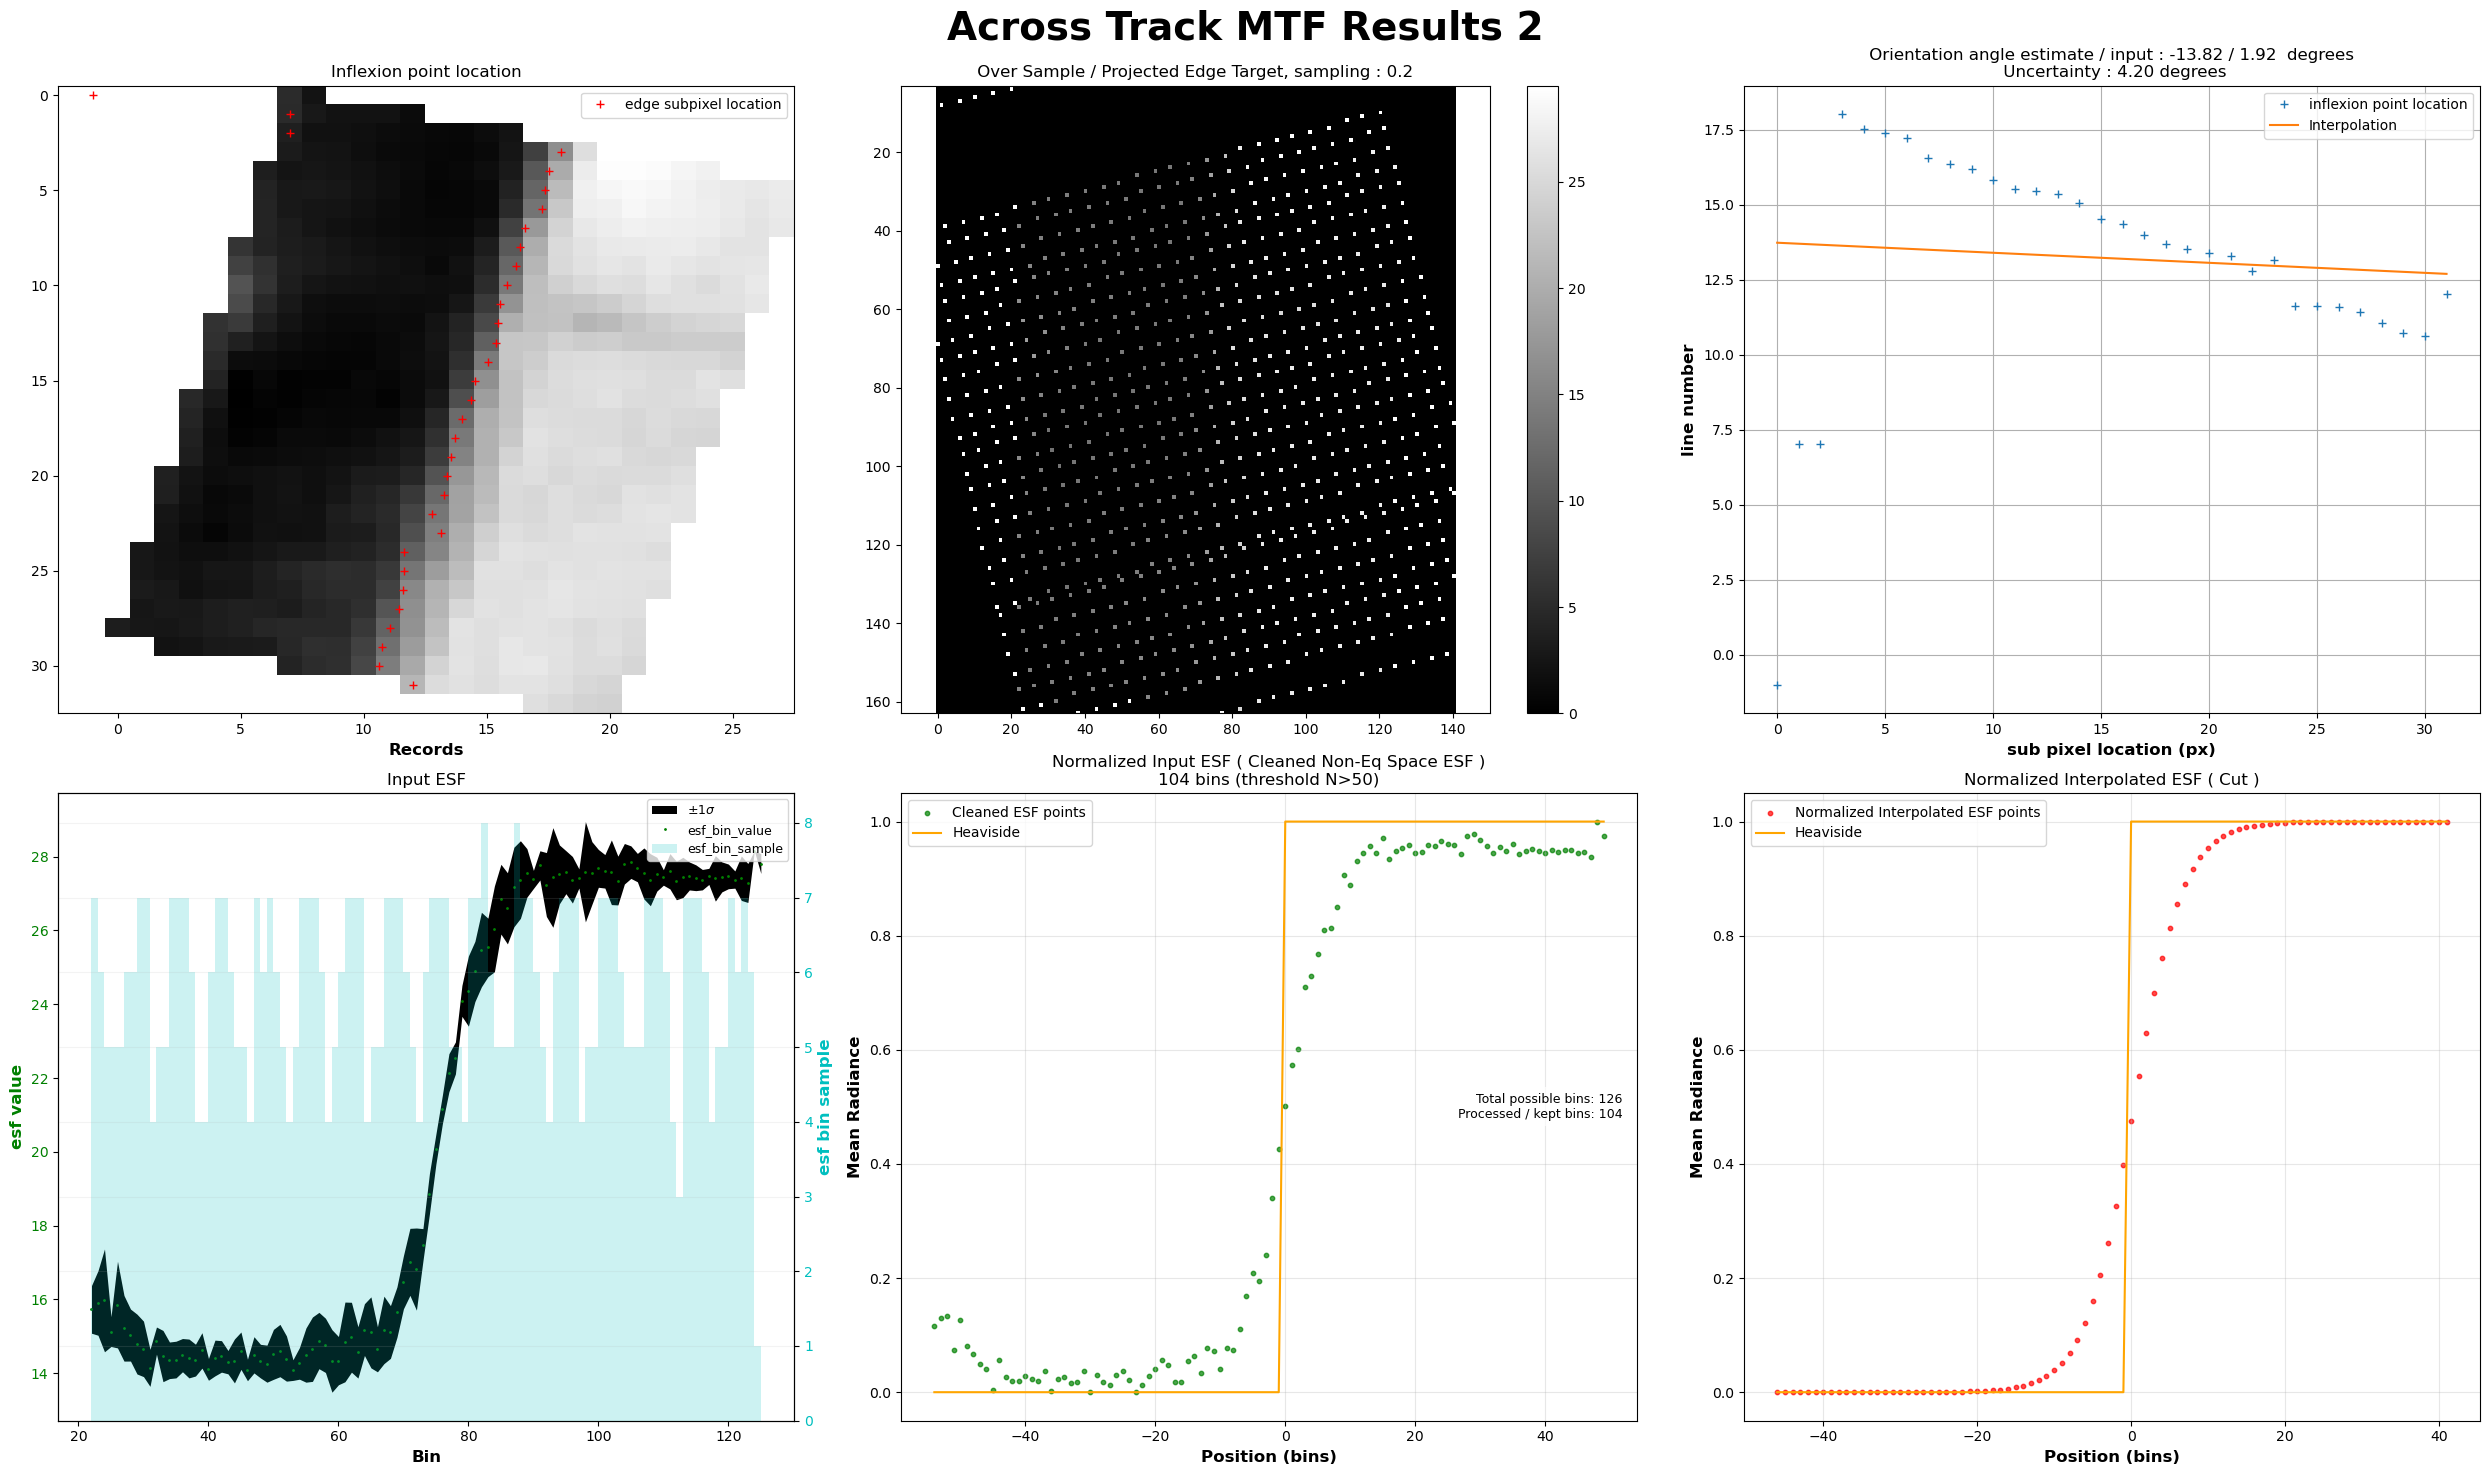


--- MTF Metrics ---
FWHM         : 2.4000 px
RER          : 0.3025
SNR          : 8.12
MTF@Nyquist  : 0.0217
Edge angle   : -13.82 deg


In [10]:
mtf_bagnolo = run_with_progress(config_bagnolo_mtf, description="MTF Bagnolo:")

fig = mtf_bagnolo.figure()
plt.tight_layout()
plt.show()

print(f"\n--- MTF Metrics ---")
print(f"FWHM         : {mtf_bagnolo.FWHM:.4f} px")
print(f"RER          : {mtf_bagnolo.RER:.4f}")
print(f"SNR          : {mtf_bagnolo.SNR:.2f}")
print(f"MTF@Nyquist  : {mtf_bagnolo.MTF_NYQ:.4f}")
print(f"Edge angle   : {mtf_bagnolo.angle:.2f} deg")

The result contains **two figures**, each with 6 subplots (2 rows × 3 columns):

**Figure 1 — MTF Results**
| Position | Content |
|----------|---------|
| Top-left | ESF, LSF, and Heaviside step function overlaid |
| Top-center | Computed metrics (method, sampling, FWHM, RER, SNR, MTF30, MTF50, MTF@Nyquist, GRD) |
| Top-right | MTF modulus vs spatial frequency with MTF30, MTF50 and Nyquist markers |
| Bottom-left | Original ESF point cloud vs interpolated ESF fit |
| Bottom-center | Normalized ESF with HEE lower/upper bounds (5%, 50%, 95%) and RER points |
| Bottom-right | Normalized LSF |

**Figure 2 — Edge Processing Details**
| Position | Content |
|----------|---------|
| Top-left | Input image with detected subpixel edge positions overlaid |
| Top-center | Oversampled / projected edge target |
| Top-right | Edge orientation angle estimate with uncertainty |
| Bottom-left | Input ESF bins with ±1σ envelope and sample count histogram |
| Bottom-center | Normalized cleaned non-equally-spaced ESF with Heaviside |
| Bottom-right | Normalized interpolated ESF (after fitting and cut) |

---
## 5. SNR on Desert Scene (Landsat-9)

We use `desert_SNR.ini`. The SNR estimator:
1. Smooths the image with a uniform filter
2. Uses **Sobel edge detection** to identify uniform (flat) regions
3. Computes noise as the difference between the original and smoothed image
4. Calculates SNR using two formulations:
   - **Formulation 1**: mean / sigma_noise (binned per radiance level)
   - **JACIE formulation**: histogram-based peak SNR estimate

=== Configuration ===
[input]
image_path = $IMAGE_QUALITY_TOOL_HOME/test/data/target4/LC09_L1TP_181040_20211121_20230505_02_T1_B5_rad_crop_2.tif
ROI = $IMAGE_QUALITY_TOOL_HOME/test/data/target4/shapefile/ROI.shp

[parameters]
# MANDATORY PARAMETERS
method = SNR
band = 1

# SNR METHOD SPECIFIC PARAMETERS
window_size = 5
snr_precision = 0.1
L_min = 100
L_max = 160

[debug]
dir = $IMAGE_QUALITY_TOOL_HOME/output/desert_m3

Debug images are being generated under: output/desert_m3


FloatProgress(value=0.0, bar_style='info', description='SNR Desert:', layout=Layout(width='50%'))

Application path not initialized
Application path not initialized
Application path not initialized
Application path not initialized
QObject::startTimer: Timers can only be used with threads started with QThread


 Band Number in the processing              : 1.00
 Scale                                      : 1.000000
 Offset                                     : 0.000000
 Input SNR precision                      : 0.1
 Width of the histogram bin is 2*c        : 0.2
Image: 959×944 = 905,296 pixels
Sampled: 4,355 points (stratified: 22×22 strata)
Ratio: 0.48%

Computing variogram...
 - Model: spherical, Estimator: dowd
SNR Computed from variogram:  24.11418103180594
Parameters fitted: (np.float64(1436.466006695983), np.float64(11.625884839949151), np.float64(13.734377013080136))
Nugget Computed from variogram:  40.725055329680444
 Minimum / Maximum Radiance of selected pixels in input: 66.53 / 182.11
 Percentage of selected pixels: 89.84 %
 Minimum / Maximum Radiance of filtered images: 100.01 / 159.98
 Statistics per bin of 1 W
 Histogram BIN Number        : 60.00
 Quadratic Error (med / mean) : 0.09
JACIE SNR Value        : 25.20 @ 108.67
Quantitative SNR Value : 30.18 @ 129.99
SNR Value (Formu

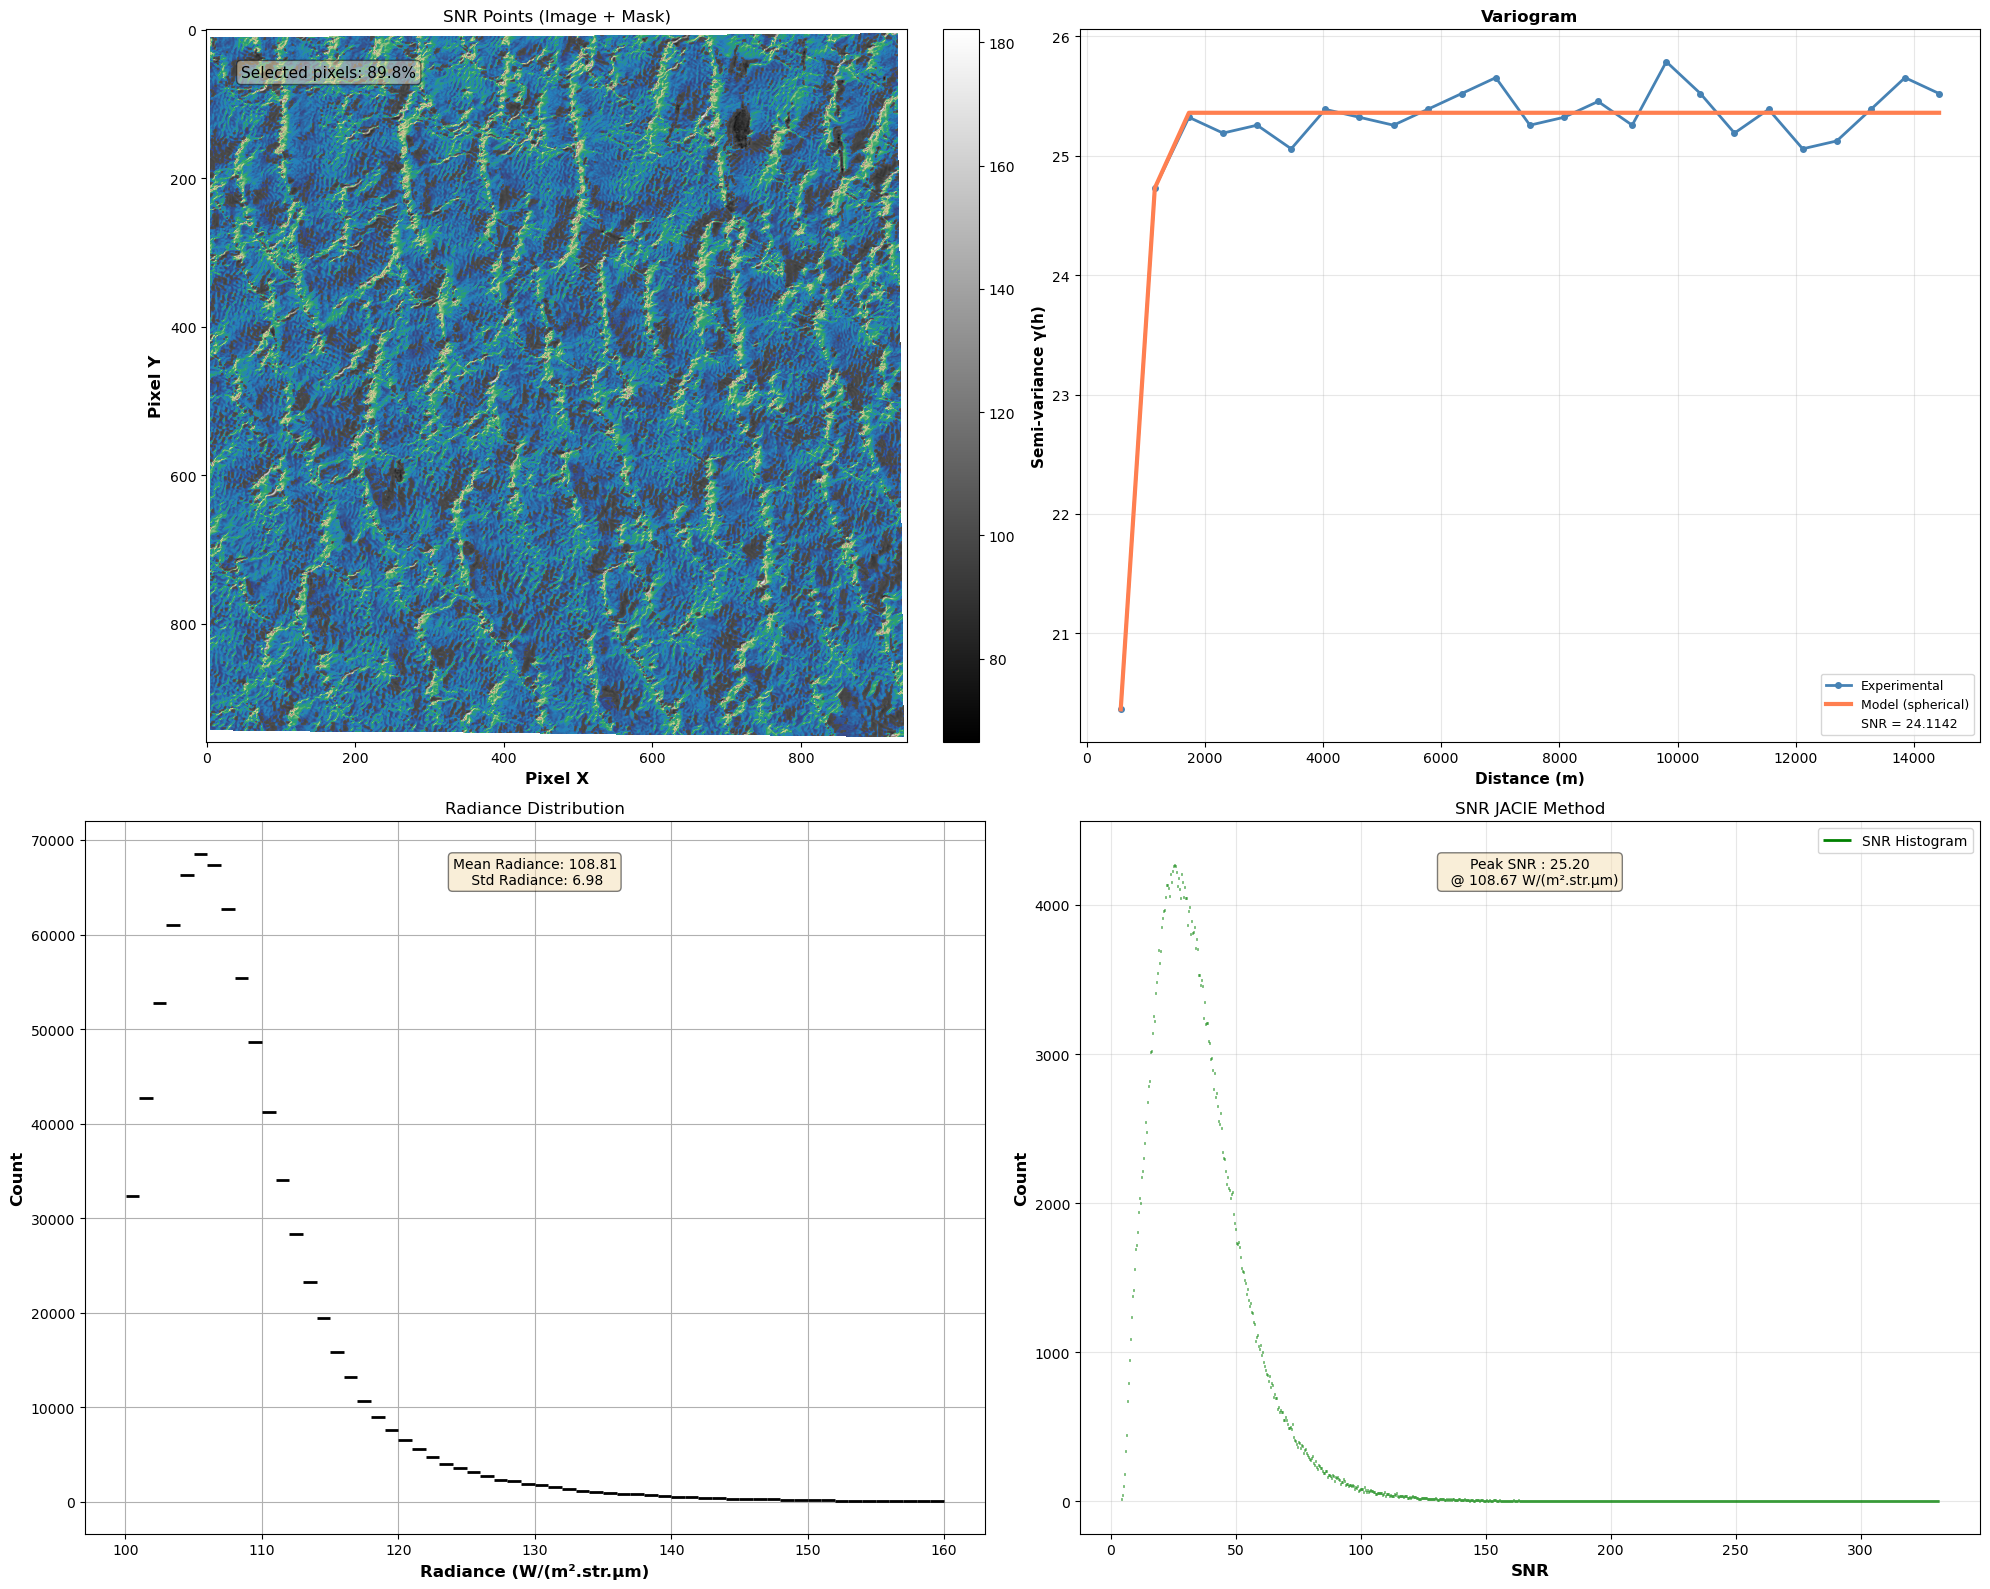

In [11]:
# Run SNR on the Landsat-9 desert dataset (shapefile ROI)
config_desert_snr = os.path.join(iqt_home, "test", "data", "config_files", "desert_SNR.ini")

print("=== Configuration ===")
with open(config_desert_snr) as f:
    print(f.read())

snr_desert = run_with_progress(config_desert_snr, description="SNR Desert:")

fig = snr_desert.figure()
plt.tight_layout()
plt.show()

---
## 6. MTF on Pléiades Neo (target3)

We use `pneo_MTF.ini` to run MTF on the Pléiades Neo MTF target scene with a shapefile ROI.

In [ ]:
# Run MTF on the Pléiades Neo target (shapefile ROI)
config_pneo_mtf = os.path.join(iqt_home, "test", "data", "config_files", "pneo_MTF.ini")

print("=== Configuration ===")
with open(config_pneo_mtf) as f:
    print(f.read())

mtf_pneo = run_with_progress(config_pneo_mtf, description="MTF Pléiades Neo:")

fig = mtf_pneo.figure()
fig.set_size_inches(12, 8)
fig.suptitle("MTF - Pléiades Neo (shapefile ROI)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n--- MTF Metrics ---")
print(f"FWHM         : {mtf_pneo.FWHM:.4f} px")
print(f"RER          : {mtf_pneo.RER:.4f}")
print(f"SNR          : {mtf_pneo.SNR:.2f}")
print(f"MTF@Nyquist  : {mtf_pneo.MTF_NYQ:.4f}")
print(f"Edge angle   : {mtf_pneo.angle:.2f} deg")

=== Configuration ===
[input]
image_path = $IMAGE_QUALITY_TOOL_HOME/test/data/target3/IMG_PNEO4_202312251040354_PMS-N_SEN_PWOI_000184796_RGB_MTF_TARGET.tif
ROI = $IMAGE_QUALITY_TOOL_HOME/test/data/target3/shapefile/roi_mtf2.shp

[parameters]
# MANDATORY PARAMETERS
method = MTF
band = 1

# METHOD 2 PARAMETERS
scale = 0.01
offset = 1.0
px_margin = 0
edge_direction = AL
esf_model = sigmoid
sampling = 0.1


[debug]
dir = $IMAGE_QUALITY_TOOL_HOME/output/pneo_m2

Debug images are being generated under: output/pneo_m2


FloatProgress(value=0.0, bar_style='info', description='MTF Pléiades Neo:', layout=Layout(width='50%'))

Application path not initialized
Application path not initialized
Application path not initialized
Application path not initialized
QObject::startTimer: Timers can only be used with threads started with QThread


 -- MTF AC Track         --
Number of processed BINs / Total : 893 / 921   :
Number of Oversample Edge Profile   : 791
PSF Extent Radius 44.1 pixels
- Compute RER on normalize Edge Spread Function
- Compute HEE on normalize Edge Spread Function
   - Edge width (period)      : 86.80 pixels
   - Nyquist @ L_w/2          : 43.40 pixels
Frequence / MTF  : 0.0000 / 1.0000
Frequence / MTF  : 0.0115 / 0.9987
Frequence / MTF  : 0.0230 / 0.9949
Frequence / MTF  : 0.0346 / 0.9886
Frequence / MTF  : 0.0461 / 0.9799
Frequence / MTF  : 0.0576 / 0.9689
Frequence / MTF  : 0.0691 / 0.9556
Frequence / MTF  : 0.0806 / 0.9403
Frequence / MTF  : 0.0922 / 0.9230
Frequence / MTF  : 0.1037 / 0.9039
Frequence / MTF  : 0.1152 / 0.8833
Frequence / MTF  : 0.1267 / 0.8612
Frequence / MTF  : 0.1382 / 0.8378
Frequence / MTF  : 0.1498 / 0.8135
Frequence / MTF  : 0.1613 / 0.7882
Frequence / MTF  : 0.1728 / 0.7622
Frequence / MTF  : 0.1843 / 0.7357
Frequence / MTF  : 0.1959 / 0.7089
Frequence / MTF  : 0.2074 / 0.6819


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

---
## 7. Bring Your Own Image

To analyze your own images:

1. **Create an INI configuration file** following the template below
2. Call `process_algorithm()` with the path to your config file

### ROI definition

There are two ways to define the Region of Interest (ROI):

- **Crop window** (pixel coordinates): `ROI = {'line': 0, 'pixel': 0, 'line_number': 100, 'pixel_number': 200}`
- **Shapefile**: `ROI = /path/to/my_roi.shp`

### Config file template

In [ ]:
# Template: copy and adapt this to create your own config file
config_template = """
[input]
image_path = /path/to/your/image.tif
ROI = {'line': 0, 'pixel': 0, 'line_number': 100, 'pixel_number': 200}
# Or use a shapefile:
# ROI = /path/to/your/shapefile/roi.shp

[parameters]
method = MTF    # MTF or SNR

band = 1        # Band number in the raster file

# MTF-specific parameters (required when method = MTF):
scale = 0.01
offset = 1.0
px_margin = 12
edge_direction = AL    # AL (Along-Track) or CT (Cross-Track)
method_type = PARAM    # PARAM or NON_PARAM
esf_model = sigmoid    # sigmoid, esf_tanh, esf_fermi, esf_gauss_exp_param

# SNR-specific parameters (required when method = SNR):
# window_size = 5
# snr_precision = 0.1
# L_min = 100
# L_max = 160

[debug]
dir = /path/to/output/directory
expert_mode = false
"""
print(config_template)

In [ ]:
# Uncomment and edit the lines below to run on your own image:

# my_config = "/path/to/my_config.ini"
# my_result = process_algorithm(my_config)
# fig = my_result.figure()
# fig.set_size_inches(12, 8)
# plt.tight_layout()
# plt.show()

---
## 8. Next Steps

- **QGIS plugin**: For interactive usage with map layers and drawn ROIs, install the toolset as a QGIS plugin (see `README.md` for instructions).
- **Command line**: Run analyses in batch mode with:
  ```bash
  python scripts/mtf_computer.py --config_file test/data/config_files/pan_target_MTF.ini
  ```
- **Debug mode**: Set `dir` in the `[debug]` section to save the result figures there. Set `expert_mode = true` to additionally save detailed step-by-step diagnostic figures to that same directory (command-line only).

In [ ]:
# Uncomment and edit the lines below to run on your own image:

# my_config = "/path/to/my_config.ini"
# my_mtf = process_algorithm(my_config)
# fig = my_mtf.figure()
# fig.set_size_inches(12, 8)
# plt.tight_layout()
# plt.show()